In [38]:
!pip install --upgrade yfinance

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
tickers = [
    "^NSEI",        # India total market
    "MON100.NS",      # International equity
    "MOSMALL250.NS",  # Small caps
    "EBBETF0430.NS"   # Bonds
]
weights = [0.3, 0.3, 0.2, 0.2]
portfolio = dict(zip(tickers, weights))

In [3]:
start_date = '2021-01-01'
end_date = '2026-01-01'

risk_free_rate = 0.0685

In [44]:
class DataLoader:
    def __init__(self, tickers, start_date = '2021-01-01', end_date= '2026-01-01'):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date

    def fetch_data(self):
        data = yf.download(
            self.tickers,
            start=self.start_date,
            end=self.end_date,
            auto_adjust=True,
            progress=False
        )["Close"]
        return data

In [5]:
class PerformanceMetrics:
    @staticmethod
    def calculate_annual_return(data):
        annual_return = data.resample('YE').last().pct_change().mean()
        return annual_return

    @staticmethod
    def calculate_annual_volatility(data):
        annual_volatility = data.pct_change(fill_method=None).std() * (252 ** 0.5)
        return annual_volatility

    @staticmethod
    def calculate_sharpe_ratio(data, risk_free_rate=risk_free_rate):
        annual_return = PerformanceMetrics.calculate_annual_return(data)
        annual_volatility = PerformanceMetrics.calculate_annual_volatility(data)
        sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
        return sharpe_ratio

    @staticmethod
    def calculate_max_drawdown(data):
        cumulative_returns = (1 + data.pct_change(fill_method=None)).cumprod()
        peak = cumulative_returns.expanding(min_periods=1).max()
        drawdown = (cumulative_returns / peak) - 1
        max_drawdown = drawdown.min()
        return max_drawdown

    @staticmethod
    def calculate_sortino_ratio(data, risk_free_rate=risk_free_rate):
        returns = data.pct_change(fill_method=None).dropna()
        downside_deviation = returns[returns < 0].std() * (252 ** 0.5)
        annual_return = PerformanceMetrics.calculate_annual_return(data)
        sortino_ratio = (annual_return - risk_free_rate) / downside_deviation
        return sortino_ratio

    @staticmethod
    def calculate_var(data, confidence_level=0.95):
        returns = data.pct_change(fill_method=None).dropna()
        var = np.percentile(returns, (1 - confidence_level) * 100)
        return var

In [6]:
class PortfolioAnalysis:
    def __init__(self, data, weights):
        self.data = data
        self.weights = np.array(weights)

        assert len(weights) == len(data.columns), "Weights must be the same length as the number of columns in the data"
        assert np.isclose(sum(weights), 1.0), "Weights must sum to 1"

    def calculate_portfolio_return(self):
        returns = self.data.pct_change(fill_method=None).mean()
        portfolio_return = np.dot(self.weights, returns) * 252
        return portfolio_return

    def calculate_portfolio_volatility(self):
        returns = self.data.pct_change(fill_method=None)
        covariance_matrix = returns.cov() * 252
        portfolio_volatility = np.sqrt(np.dot(self.weights.T, np.dot(covariance_matrix, self.weights)))
        return portfolio_volatility

    def calculate_portfolio_sharpe_ratio(self, risk_free_rate=risk_free_rate):
        portfolio_return = self.calculate_portfolio_return()
        portfolio_volatility = self.calculate_portfolio_volatility()
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
        return sharpe_ratio

In [7]:
class PortfolioVisualization:
    @staticmethod
    def plot_performance(data):
        cumulative_returns = (1 + data.pct_change(fill_method=None)).cumprod()
        cumulative_returns.plot(figsize=(10, 6))
        plt.title('Portfolio Component Cumulative Returns')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Returns')
        plt.grid(True)
        plt.show()

    @staticmethod
    def plot_portfolio_return(data, weights):
        returns = data.pct_change(fill_method=None).dropna()
        weighted_returns = returns.dot(weights)
        cumulative_portfolio_returns = (1 + weighted_returns).cumprod()
        cumulative_portfolio_returns.plot(figsize=(10, 6))
        plt.title('Total Portfolio Cumulative Return')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Returns')
        plt.grid(True)
        plt.show()

In [8]:
class BenchmarkComparison:

    BENCHMARKS = {
        "^NSEI": "Nifty 50",
        "^BSESN": "Sensex",
        "MON100.NS": "Nasdaq 100",
        "MOTY.NS": "Nifty 500 ETF",
        "EBBETF0430.NS": "Bharat Bond ETF"
    }

    
    def __init__(self, portfolio_data, weights, benchmark_ticker='SPY', risk_free_rate=.0685):
        self.portfolio_data = portfolio_data
        self.weights = np.array(weights)
        self.benchmark_ticker = benchmark_ticker
        self.risk_free_rate = risk_free_rate

        returns = portfolio_data.pct_change(fill_method=None).dropna()
        self.portfolio_returns = returns.dot(self.weights)

        self.benchmark_data = self._fetch_benchmark()
        
        self.benchmark_returns = self.benchmark_data.pct_change(fill_method=None).dropna().squeeze()


        common_dates = self.portfolio_returns.index.intersection(self.benchmark_returns.index)
        self.portfolio_returns = self.portfolio_returns.loc[common_dates]
        self.benchmark_returns = self.benchmark_returns.loc[common_dates]

    def _fetch_benchmark(self):
        start_date = self.portfolio_data.index.min()
        end_date = self.portfolio_data.index.max()
        
        benchmark = yf.download(self.benchmark_ticker, start=start_date, end=end_date, progress=False)['Close'].squeeze()
        return benchmark

    def calculate_beta(self):
        covariance = self.portfolio_returns.cov(self.benchmark_returns)
        benchmark_variance = self.benchmark_returns.var()
        beta = covariance / benchmark_variance
        return beta

    def calculate_alpha(self, annualized=True):
        beta = self.calculate_beta()
        portfolio_mean = self.portfolio_returns.mean()
        benchmark_mean = self.benchmark_returns.mean()
        rf_daily = self.risk_free_rate / 252

        alpha = portfolio_mean - (rf_daily + beta * (benchmark_mean - rf_daily))
        if annualized:
            alpha = alpha * 252
        
        return alpha

    def calculate_tracking_error(self, annualized=True):
        active_returns = self.portfolio_returns - self.benchmark_returns
        tracking_error = active_returns.std()
        
        if annualized:
            tracking_error = tracking_error * np.sqrt(252)
        
        return tracking_error

    def calculate_information_ratio(self):
        active_return = (self.portfolio_returns.mean() - self.benchmark_returns.mean()) * 252
        tracking_error = self.calculate_tracking_error(annualized=True)
        
        if tracking_error == 0:
            return np.inf if active_return > 0 else -np.inf
        
        return active_return / tracking_error

    def calculate_correlation(self):
        return np.corrcoef(self.portfolio_returns.squeeze(), self.benchmark_returns.squeeze())[0, 1]

    def calculate_r_squared(self):
        correlation = self.calculate_correlation()
        return correlation ** 2

    def calculate_up_capture(self):
        up_mask = self.benchmark_returns > 0
        if up_mask.sum() == 0:
            return np.nan
        
        portfolio_up = self.portfolio_returns[up_mask].mean()
        benchmark_up = self.benchmark_returns[up_mask].mean()
        
        return (portfolio_up / benchmark_up) * 100

    def calculate_down_capture(self):
        down_mask = self.benchmark_returns < 0
        if down_mask.sum() == 0:
            return np.nan
        
        portfolio_down = self.portfolio_returns[down_mask].mean()
        benchmark_down = self.benchmark_returns[down_mask].mean()
        
        return (portfolio_down / benchmark_down) * 100

    def generate_report(self):
        print("\n" + "="*60)
        print("BENCHMARK COMPARISON REPORT")
        print("="*60)
        print(f"Benchmark: {self.benchmark_ticker}", end="")
        if self.benchmark_ticker in self.BENCHMARKS:
            print(f" ({self.BENCHMARKS[self.benchmark_ticker]})")
        else:
            print()
        print(f"Period: {self.portfolio_returns.index.min().strftime('%Y-%m-%d')} to {self.portfolio_returns.index.max().strftime('%Y-%m-%d')}")
        print("-"*60)

        # Returns
        port_annual_return = float(self.portfolio_returns.mean() * 252 * 100)
        bench_annual_return = float(self.benchmark_returns.mean() * 252 * 100)
        print("\nAnnualized Returns:")
        print(f"  Portfolio:  {port_annual_return:.2f}%")
        print(f"  Benchmark:  {bench_annual_return:.2f}%")
        print(f"  Difference: {port_annual_return - bench_annual_return:+.2f}%")

        # Volatility
        port_vol = float(self.portfolio_returns.std() * np.sqrt(252) * 100)
        bench_vol = float(self.benchmark_returns.std() * np.sqrt(252) * 100)
        print("\nAnnualized Volatility:")
        print(f"  Portfolio:  {port_vol:.2f}%")
        print(f"  Benchmark:  {bench_vol:.2f}%")
        
        # Risk metrics
        print("\nRisk Metrics:")
        print(f"  Beta:              {self.calculate_beta():.3f}")
        print(f"  Alpha (annual):    {self.calculate_alpha()*100:.2f}%")
        print(f"  R-squared:         {self.calculate_r_squared():.3f}")
        print(f"  Correlation:       {self.calculate_correlation():.3f}")
        
        # Performance metrics
        print("\nPerformance Metrics:")
        print(f"  Tracking Error:    {self.calculate_tracking_error()*100:.2f}%")
        print(f"  Information Ratio: {self.calculate_information_ratio():.3f}")
        print(f"  Up Capture:        {self.calculate_up_capture():.1f}%")
        print(f"  Down Capture:      {self.calculate_down_capture():.1f}%")
        print("="*60)

    def plot_cumulative_returns(self, initial_value=10000):
        portfolio_cum = (1 + self.portfolio_returns).cumprod() * initial_value
        benchmark_cum = (1 + self.benchmark_returns).cumprod() * initial_value
        
        plt.figure(figsize=(12, 6))
        
        plt.plot(portfolio_cum.index, portfolio_cum.values, 
                label='Portfolio', linewidth=2, color='blue')
        plt.plot(benchmark_cum.index, benchmark_cum.values, 
                label=f'Benchmark ({self.benchmark_ticker})', linewidth=2, color='orange')
        
        plt.title('Cumulative Returns: Portfolio vs Benchmark')
        plt.xlabel('Date')
        plt.ylabel(f'Value (starting from {initial_value:,.0f})')
        plt.legend()
        plt.grid(True, alpha=0.3)

        final_port = portfolio_cum.iloc[-1]
        final_bench = benchmark_cum.iloc[-1]

        plt.annotate(f'{final_port:,.0f}', 
                    xy=(portfolio_cum.index[-1], final_port),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=9, color='blue')
        plt.annotate(f'{final_bench:,.0f}', 
                    xy=(benchmark_cum.index[-1], final_bench),
                    xytext=(10, -15), textcoords='offset points',
                    fontsize=9, color='orange')

        plt.tight_layout()
        plt.show()

    def plot_rolling_metrics(self, window=252):
        rolling_beta = []
        rolling_alpha = []
        dates = []

        for i in range(window, len(self.portfolio_returns)):
            port_window = self.portfolio_returns.iloc[i-window:i]
            bench_window = self.benchmark_returns.iloc[i-window:i]
            
            # Beta
            cov = np.cov(port_window, bench_window)[0, 1]
            var = np.var(bench_window)
            beta = cov / var
            
            # Alpha (annualized)
            rf_daily = self.risk_free_rate / 252
            alpha = (port_window.mean() - (rf_daily + beta * (bench_window.mean() - rf_daily))) * 252
            
            rolling_beta.append(beta)
            rolling_alpha.append(alpha)
            dates.append(self.portfolio_returns.index[i])


        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        axes[0].plot(dates, rolling_beta, linewidth=1.5, color='blue')
        axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=1, label='Beta = 1.0')
        axes[0].set_ylabel('Beta')
        axes[0].set_title(f'Rolling {window}-Day Beta and Alpha')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(dates, [a * 100 for a in rolling_alpha], linewidth=1.5, color='green')
        axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, label='Alpha = 0')
        axes[1].set_ylabel('Alpha (%)')
        axes[1].set_xlabel('Date')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()             

In [9]:
tickers = [
    "^NSEI",        # India total market
    "MON100.NS",      # International equity
    "MOSMALL250.NS",  # Small caps
    "EBBETF0430.NS"   # Bonds
]
weights = [0.3, 0.3, 0.2, 0.2]
portfolio = dict(zip(tickers, weights))

In [10]:
data_loader = DataLoader(tickers, start_date, end_date)
data = data_loader.fetch_data()

In [11]:
# Calculate performance metrics
annual_return = PerformanceMetrics.calculate_annual_return(data)
annual_volatility = PerformanceMetrics.calculate_annual_volatility(data)
sharpe_ratio = PerformanceMetrics.calculate_sharpe_ratio(data)
max_drawdown = PerformanceMetrics.calculate_max_drawdown(data)
sortino_ratio = PerformanceMetrics.calculate_sortino_ratio(data)
var = PerformanceMetrics.calculate_var(data)

In [12]:
print('\n********** Individual Ticker Stats **********')
print("\nAnnual Return (%):", np.round(100*annual_return, 2))
print("\nAnnual Volatility (%):", np.round(100*annual_volatility, 2))
print("\nSharpe Ratio:", np.round(sharpe_ratio, 2))
print("\nMax Drawdown (%):", np.round(100*max_drawdown, 2))
print("\nSortino Ratio:", np.round(sortino_ratio, 2))
print("\nValue at Risk (VaR):", np.round(var, 2))


********** Individual Ticker Stats **********

Annual Return (%): Ticker
EBBETF0430.NS     7.01
MON100.NS        23.07
MOSMALL250.NS    -5.63
^NSEI            10.92
dtype: float64

Annual Volatility (%): Ticker
EBBETF0430.NS      3.05
MON100.NS        405.61
MOSMALL250.NS     18.51
^NSEI             13.99
dtype: float64

Sharpe Ratio: Ticker
EBBETF0430.NS    0.05
MON100.NS        0.04
MOSMALL250.NS   -0.67
^NSEI            0.29
dtype: float64

Max Drawdown (%): Ticker
EBBETF0430.NS    -3.51
MON100.NS       -90.28
MOSMALL250.NS   -26.09
^NSEI           -17.23
dtype: float64

Sortino Ratio: Ticker
EBBETF0430.NS    0.07
MON100.NS        0.97
MOSMALL250.NS   -0.86
^NSEI            0.42
dtype: float64

Value at Risk (VaR): -0.01


In [13]:
# Perform portfolio analysis
portfolio_analysis = PortfolioAnalysis(data, weights)
portfolio_return = portfolio_analysis.calculate_portfolio_return()
portfolio_volatility = portfolio_analysis.calculate_portfolio_volatility()
portfolio_sharpe_ratio = portfolio_analysis.calculate_portfolio_sharpe_ratio()

In [14]:
print('\n********** Portfolio Return Stats **********')
print("Portfolio Return (%):", np.round(100*portfolio_return, 2))
print("Portfolio Volatility (%):", np.round(100*portfolio_volatility, 2))
print("Portfolio Sharpe Ratio:", np.round(portfolio_sharpe_ratio, 2))


********** Portfolio Return Stats **********
Portfolio Return (%): 62.53
Portfolio Volatility (%): 121.99
Portfolio Sharpe Ratio: 0.46


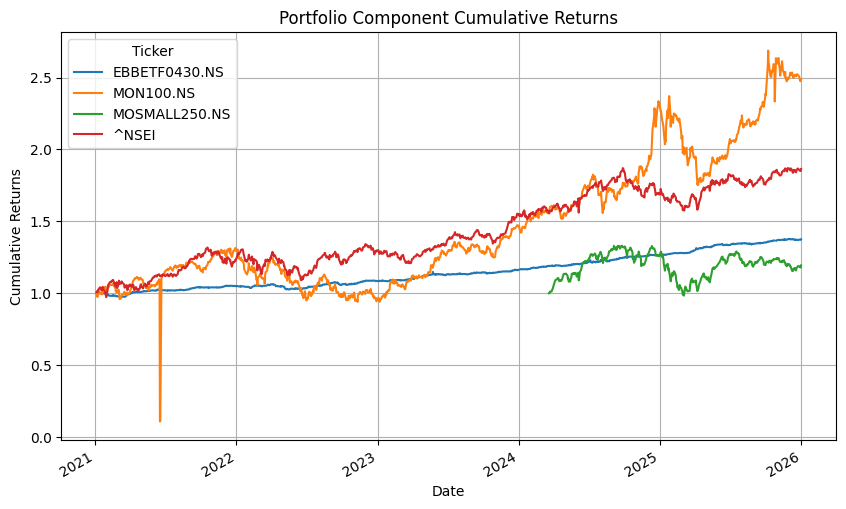

In [15]:
# Visualize portfolio performance
PortfolioVisualization.plot_performance(data)

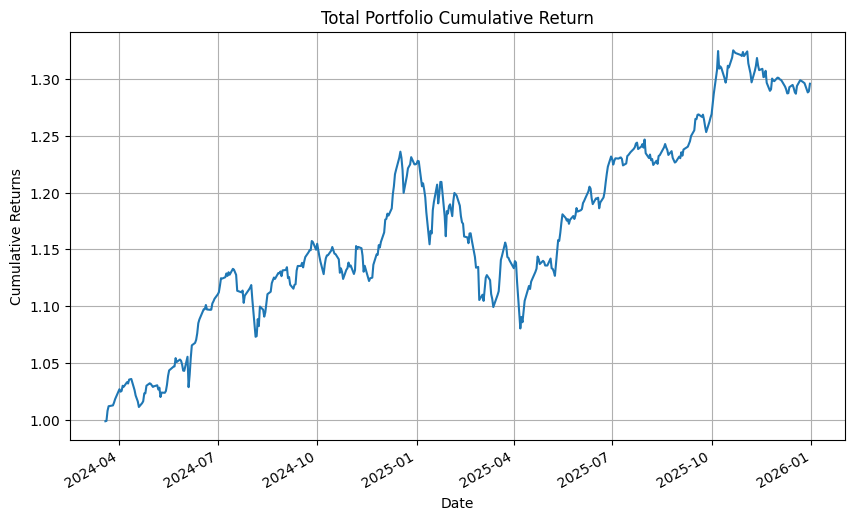

In [16]:
PortfolioVisualization.plot_portfolio_return(data, weights)


BENCHMARK COMPARISON REPORT
Benchmark: ^NSEI (Nifty 50)
Period: 2024-03-19 to 2025-12-30
------------------------------------------------------------

Annualized Returns:
  Portfolio:  15.15%
  Benchmark:  10.00%
  Difference: +5.15%

Annualized Volatility:
  Portfolio:  10.64%
  Benchmark:  13.06%

Risk Metrics:
  Beta:              0.597
  Alpha (annual):    6.42%
  R-squared:         0.537
  Correlation:       0.733

Performance Metrics:
  Tracking Error:    8.95%
  Information Ratio: 0.575
  Up Capture:        65.9%
  Down Capture:      53.2%


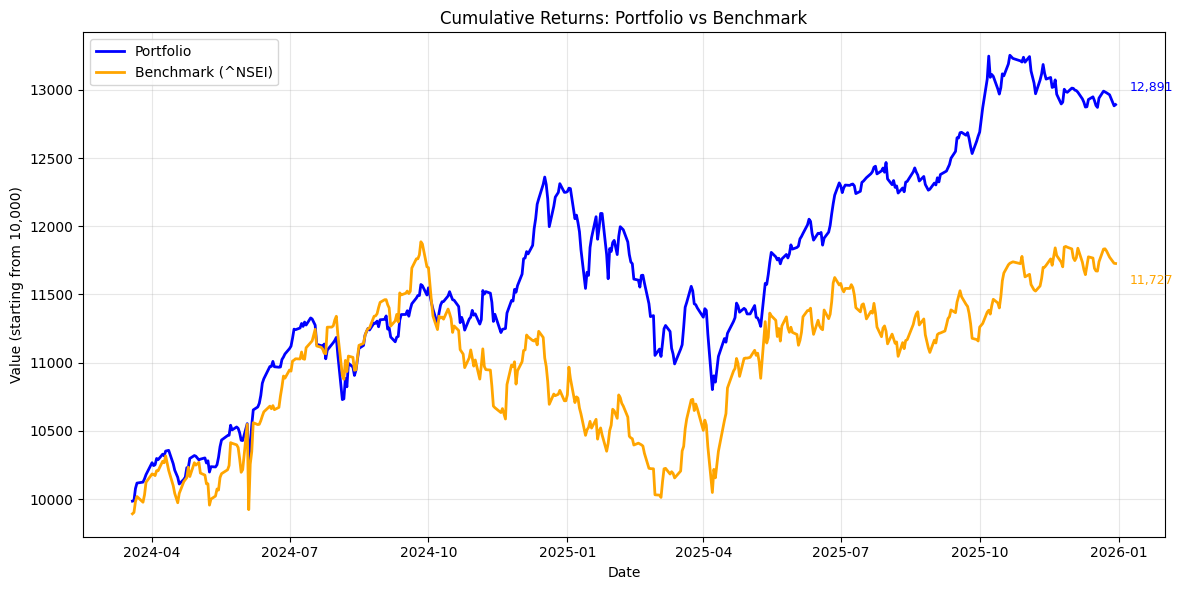

In [17]:
# Compare portfolio against S&P 500 benchmark
benchmark = BenchmarkComparison(data, weights, benchmark_ticker='^NSEI', risk_free_rate=risk_free_rate)
benchmark.generate_report()
benchmark.plot_cumulative_returns()

In [24]:
class MonteCarloSimulation:
    def __init__(self, data, weights, num_simulations=1000, time_horizon=252, initial_investment=10000):
        self.data = data
        self.weights = np.array(weights)
        self.num_simulations = num_simulations
        self.time_horizon = time_horizon
        self.initial_investment = initial_investment


        assert len(self.weights) == len(data.columns), "Weights must match number of assets"
        assert np.isclose(sum(self.weights), 1.0), "Weights must sum to 1.0"

        self._results = None
        print("\nInitializing Monte Carlo Simulation")
        print("-" * 60)
        
        for ticker, weight in zip(data.keys(), weights):
            if weight > 0.001:
                print(f"{ticker:<15}: {weight:>7.2%}")
        
        print("-" * 60)
        print(f"Simulations  : {num_simulations:,}")
        print(f"Time Horizon : {time_horizon} trading days")
        print("-" * 60)


    def simulate(self):
        returns = self.data.pct_change().dropna()
        mean_returns = returns.mean().values
        cov_matrix = returns.cov().values

        results = np.zeros((self.num_simulations, self.time_horizon))

        for i in range(self.num_simulations):
            sim_returns = np.random.multivariate_normal(mean_returns, cov_matrix, self.time_horizon)
            portfolio_returns = sim_returns @ self.weights

            portfolio_returns = np.clip(portfolio_returns, -0.30, 0.30)

            cumulative_returns = np.cumprod(1 + portfolio_returns)
            results[i, :] = self.initial_investment * cumulative_returns


        self._results = results
        return results


    def get_statistics(self, percentiles=[5, 25, 50, 75, 95]):
        if self._results is None:
            self.simulate()
        
        results = self._results
        final_values = results[:, -1]


        stats = {
            'percentiles': {p: np.percentile(results, p, axis=0) for p in percentiles},
            'mean': np.mean(results, axis=0),
            'std': np.std(results, axis=0),
            'final_values': {
                'mean': np.mean(final_values),
                'median': np.median(final_values),
                'std': np.std(final_values),
                'min': np.min(final_values),
                'max': np.max(final_values),
                'percentile_5': np.percentile(final_values, 5),
                'percentile_95': np.percentile(final_values, 95),
                'prob_loss': np.mean(final_values < self.initial_investment) * 100
            }
        }
        return stats

    def plot_simulation(self, show_percentiles=True, num_paths=100):
        if self._results is None:
            self.simulate()
    
        results = self._results
        stats = self.get_statistics()

        plt.figure(figsize=(12, 7))
        
        # Plot a subset of individual paths (semi-transparent)
        paths_to_plot = min(num_paths, self.num_simulations)
        for i in range(paths_to_plot):
            plt.plot(results[i, :], color='lightblue', alpha=0.3, linewidth=0.5)
        
        if show_percentiles:
            days = np.arange(self.time_horizon)

            plt.fill_between(days, 
                           stats['percentiles'][5], 
                           stats['percentiles'][95],
                           color='blue', alpha=0.2, label='5th-95th percentile')
            plt.fill_between(days,
                           stats['percentiles'][25],
                           stats['percentiles'][75],
                           color='blue', alpha=0.3, label='25th-75th percentile')

            plt.plot(stats['percentiles'][50], color='darkblue', 
                    linewidth=2, label='Median (50th percentile)')

        #Plot initial investment line
        plt.axhline(y=self.initial_investment, color='red', 
                   linestyle='--', linewidth=1, label=f'Initial: ${self.initial_investment:,.0f}')

        plt.title(f'Monte Carlo Simulation ({self.num_simulations:,} paths, {self.time_horizon} days)')
        plt.xlabel('Trading Days')
        plt.ylabel('Portfolio Value ($)')
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)

         # Add summary statistics text box
        final_stats = stats['final_values']
        textstr = f"Final Value Statistics:\n"
        textstr += f"Median: {final_stats['median']:,.0f}\n"
        textstr += f"5th %%: {final_stats['percentile_5']:,.0f}\n"
        textstr += f"95th %%: {final_stats['percentile_95']:,.0f}\n"
        textstr += f"Prob. of Loss: {final_stats['prob_loss']:.1f}%"
        
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        plt.text(0.98, 0.02, textstr, transform=plt.gca().transAxes, 
                fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                bbox=props)
        
        plt.tight_layout()
        plt.show()


    def print_summary(self):        
        """Print a summary of simulation results."""
        if self._results is None:
            self.simulate()
            
        stats = self.get_statistics()
        final = stats['final_values']
        
        print("\n" + "="*50)
        print("MONTE CARLO SIMULATION SUMMARY")
        print("="*50)
        print(f"Initial Investment: {self.initial_investment:,.0f}")
        print(f"Time Horizon: {self.time_horizon} trading days")
        print(f"Number of Simulations: {self.num_simulations:,}")
        print("-"*50)
        print("Final Portfolio Value Statistics:")
        print(f"  Mean:     {final['mean']:,.0f}")
        print(f"  Median:   {final['median']:,.0f}")
        print(f"  Std Dev:  {final['std']:,.0f}")
        print(f"  Min:      {final['min']:,.0f}")
        print(f"  Max:      {final['max']:,.0f}")
        print("-"*50)
        print("Percentile Projections:")
        print(f"  5th percentile:  {final['percentile_5']:,.0f}")
        print(f"  95th percentile: {final['percentile_95']:,.0f}")
        print("-"*50)
        print(f"Probability of Loss: {final['prob_loss']:.1f}%")
        print("="*50)


    
    

In [33]:
def optimize_portfolio(data, risk_free_rate=0.0685):
    tickers = list(data.keys())
    prices = data
    returns = prices.pct_change().dropna()
    mu = returns.mean().reindex(tickers) * 252
    cov = (
        returns.cov()
        .reindex(index=tickers, columns=tickers)
        * 252
    )

    n_assets = len(tickers)

    def negative_sharpe(weights):
        portfolio_return = weights @ mu
        portfolio_volatility = np.sqrt(weights @ cov @ weights)
        sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility
        return -sharpe

    constraints = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
    )

    bounds = [(0, 0.25)] * n_assets

    initial_weights = np.ones(n_assets) / n_assets

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    optimal_weights = result.x

    portfolio_return = optimal_weights @ mu
    portfolio_volatility = np.sqrt(
        optimal_weights @ cov @ optimal_weights
    )

    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    return {
        "tickers": tickers,
        "weights": optimal_weights,
        "weights_dict": dict(
            zip(tickers, np.round(optimal_weights, 4))
        ),
        "expected_return": float(portfolio_return),
        "volatility": float(portfolio_volatility),
        "sharpe_ratio": float(sharpe_ratio)
    }

def print_portfolio_optimization(result):
    print("\n" + "=" * 60)
    print("PORTFOLIO OPTIMIZATION RESULTS")
    print("=" * 60)

    print("\nOptimal Weights")
    print("-" * 60)

    sorted_weights = sorted(
        zip(result["tickers"], result["weights"]),
        key=lambda x: x[1],
        reverse=True
    )

    for ticker, weight in sorted_weights:
        print(f"{ticker:<15} {weight:>8.2%}")

    print("\nPortfolio Metrics")
    print("-" * 60)
    print(f"Expected Annual Return : {result['expected_return']:.2%}")
    print(f"Annual Volatility      : {result['volatility']:.2%}")
    print(f"Sharpe Ratio           : {result['sharpe_ratio']:.3f}")

    print("=" * 60)

In [34]:
portfolio = {
    "RELIANCE.NS": 0.2,
    "HDFCBANK.NS": 0.2,
    "TCS.NS": 0.2,
    "MON100.NS": 0.2,
    "GOLDBEES.NS": 0.2
}

result = optimize_portfolio(data)

print_portfolio_optimization(result)


PORTFOLIO OPTIMIZATION RESULTS

Optimal Weights
------------------------------------------------------------
EBBETF0430.NS     25.00%
GOLDBEES.NS       25.00%
BHARTIARTL.NS     16.73%
MON100.NS         12.47%
HDFCBANK.NS        9.10%
MARUTI.NS          7.00%
BAJFINANCE.NS      2.83%
SBIN.NS            1.74%
HINDUNILVR.NS      0.12%
ITC.NS             0.00%
SUNPHARMA.NS       0.00%
ASIANPAINT.NS      0.00%
AXISBANK.NS        0.00%
HCLTECH.NS         0.00%
ICICIBANK.NS       0.00%
INFY.NS            0.00%
JUNIORBEES.NS      0.00%
KOTAKBANK.NS       0.00%
LT.NS              0.00%
MOSMALL250.NS      0.00%
NIFTYBEES.NS       0.00%
RELIANCE.NS        0.00%
TCS.NS             0.00%
TITAN.NS           0.00%
ULTRACEMCO.NS      0.00%
WIPRO.NS           0.00%
^BSESN             0.00%
^NSEI              0.00%

Portfolio Metrics
------------------------------------------------------------
Expected Annual Return : 26.42%
Annual Volatility      : 8.22%
Sharpe Ratio           : 2.380


C:\Users\Vinayak\AppData\Local\Temp\ipykernel_28204\3956879402.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()
C:\Users\Vinayak\AppData\Local\Temp\ipykernel_28204\2148711415.py:28: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = self.data.pct_change().dropna()



Initializing Monte Carlo Simulation
------------------------------------------------------------
GOLDBEES.NS    :  25.00%
HDFCBANK.NS    :  25.00%
MON100.NS      :   2.85%
RELIANCE.NS    :  25.00%
TCS.NS         :  22.15%
------------------------------------------------------------
Simulations  : 1,000
Time Horizon : 252 trading days
------------------------------------------------------------

MONTE CARLO SIMULATION SUMMARY
Initial Investment: 10,000
Time Horizon: 252 trading days
Number of Simulations: 1,000
--------------------------------------------------
Final Portfolio Value Statistics:
  Mean:     11,929
  Median:   11,776
  Std Dev:  1,961
  Min:      6,135
  Max:      20,006
--------------------------------------------------
Percentile Projections:
  5th percentile:  8,961
  95th percentile: 15,395
--------------------------------------------------
Probability of Loss: 16.1%


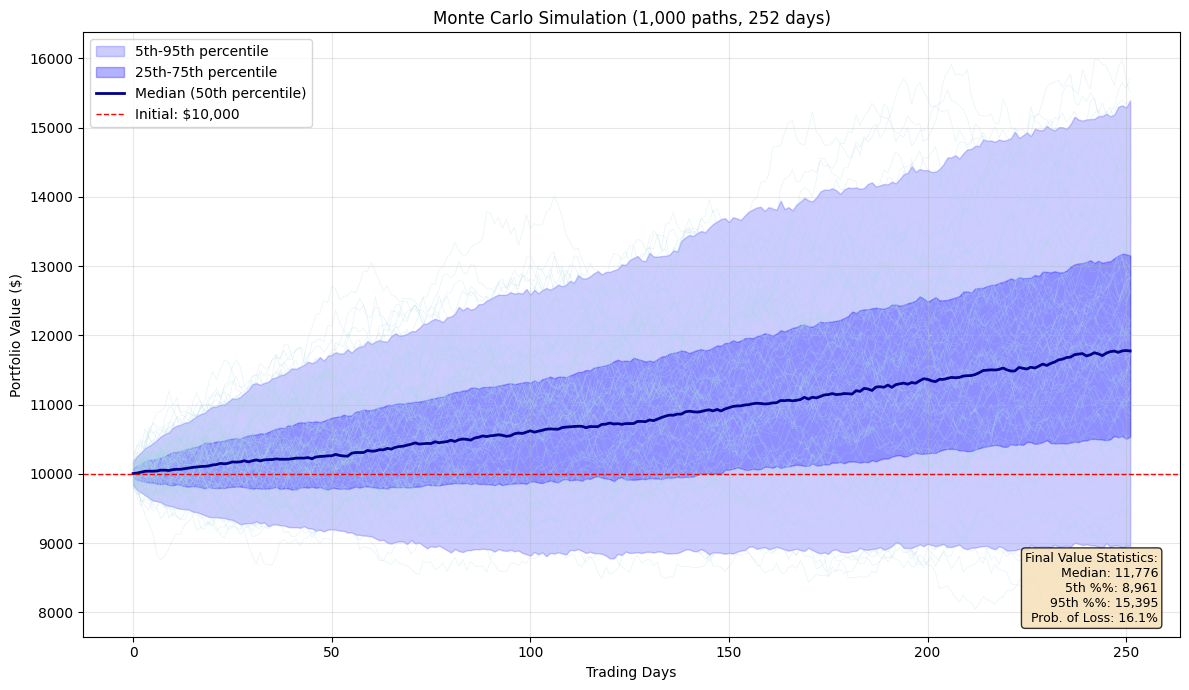

In [35]:
tickers = list(portfolio.keys())

data_loader = DataLoader(tickers, start_date, end_date)
data = data_loader.fetch_data()

result = optimize_portfolio(data)

mc_sim = MonteCarloSimulation(
    data,
    weights=result["weights"],
    num_simulations=1000,
    time_horizon=252
)

mc_sim.print_summary()
mc_sim.plot_simulation()

In [36]:
portfolio = {
    "RELIANCE.NS": 0.05,
    "HDFCBANK.NS": 0.05,
    "ICICIBANK.NS": 0.05,
    "SBIN.NS": 0.05,
    "TCS.NS": 0.05,
    "INFY.NS": 0.05,
    "HINDUNILVR.NS": 0.05,
    "ITC.NS": 0.05,
    "BHARTIARTL.NS": 0.05,
    "LT.NS": 0.05,
    "SUNPHARMA.NS": 0.05,
    "MARUTI.NS": 0.1,
    "ASIANPAINT.NS": 0.05,
    "BAJFINANCE.NS": 0.05,
    "GOLDBEES.NS": 0.10,
    "MON100.NS": 0.10
}

Effective data range: 2021-01-01 to 2025-12-31

Initializing Monte Carlo Simulation
------------------------------------------------------------
BHARTIARTL.NS  :  25.00%
GOLDBEES.NS    :  25.00%
ITC.NS         :   8.66%
LT.NS          :   8.03%
MARUTI.NS      :   1.69%
MON100.NS      :   0.70%
SBIN.NS        :  12.25%
SUNPHARMA.NS   :  18.67%
------------------------------------------------------------
Simulations  : 1,000
Time Horizon : 252 trading days
------------------------------------------------------------

MONTE CARLO SIMULATION SUMMARY
Initial Investment: 10,000
Time Horizon: 252 trading days
Number of Simulations: 1,000
--------------------------------------------------
Final Portfolio Value Statistics:
  Mean:     13,134
  Median:   13,028
  Std Dev:  1,549
  Min:      8,760
  Max:      19,890
--------------------------------------------------
Percentile Projections:
  5th percentile:  10,767
  95th percentile: 15,729
--------------------------------------------------
Proba

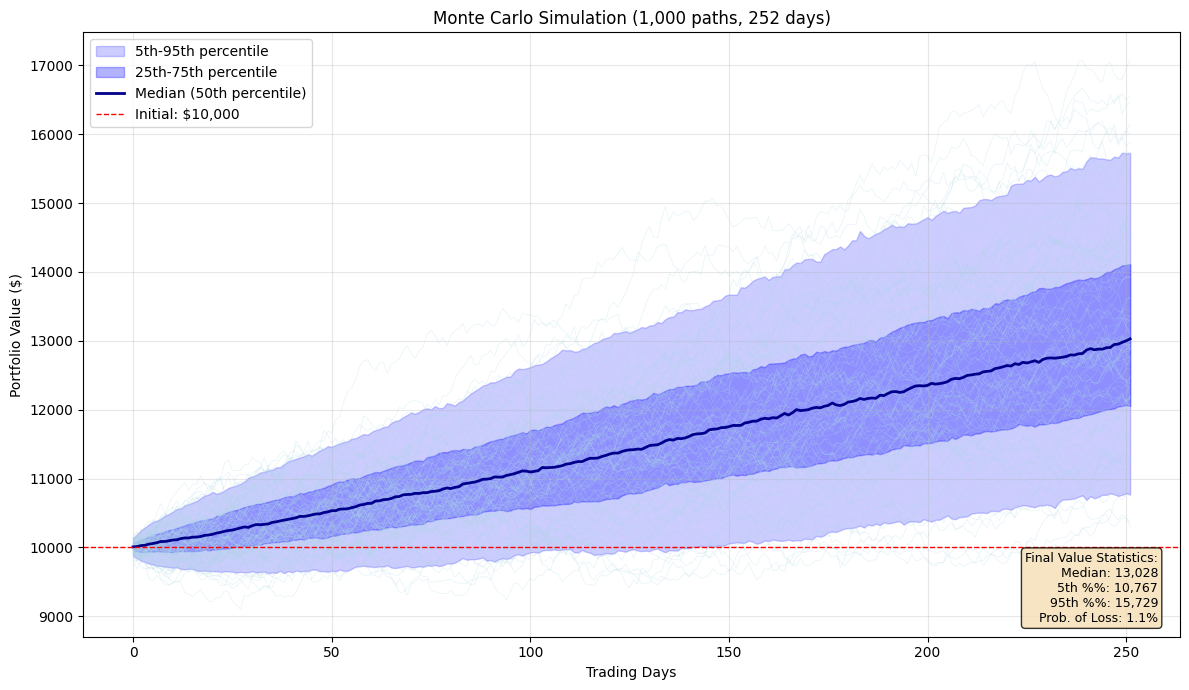

In [37]:
tickers = list(portfolio.keys())

data_loader = DataLoader(tickers, start_date, end_date)
data = data_loader.fetch_data()
data = data.dropna()  # drops rows where any ticker has no data
print(f"Effective data range: {data.index[0].date()} to {data.index[-1].date()}")

returns = data.pct_change().dropna()

# Flag any ticker with suspicious daily returns
for col in returns.columns:
    max_ret = returns[col].abs().max()
    if max_ret > 0.25:
        print(f"WARNING: {col} has a daily return of {max_ret:.1%} — check data quality")

result = optimize_portfolio(data)

mc_sim = MonteCarloSimulation(
    data,
    weights=result["weights"],
    num_simulations=1000,
    time_horizon=252
)

mc_sim.print_summary()
mc_sim.plot_simulation()

In [38]:
# Large Cap Stocks (NSE)
portfolio_tokens = {
    # --- Large Cap Equities ---
    "RELIANCE.NS":    "Reliance Industries",
    "TCS.NS":         "Tata Consultancy Services",
    "HDFCBANK.NS":    "HDFC Bank",
    "ICICIBANK.NS":   "ICICI Bank",
    "INFY.NS":        "Infosys",
    "SBIN.NS":        "State Bank of India",
    "BHARTIARTL.NS":  "Bharti Airtel",
    "LT.NS":          "Larsen & Toubro",
    "ITC.NS":         "ITC",
    "KOTAKBANK.NS":   "Kotak Mahindra Bank",
    "AXISBANK.NS":    "Axis Bank",
    "WIPRO.NS":       "Wipro",
    "HCLTECH.NS":     "HCL Technologies",
    "SUNPHARMA.NS":   "Sun Pharmaceutical",
    "MARUTI.NS":      "Maruti Suzuki",
    "BAJFINANCE.NS":  "Bajaj Finance",
    "TITAN.NS":       "Titan Company",
    "ULTRACEMCO.NS":  "UltraTech Cement",
    "HINDUNILVR.NS":  "Hindustan Unilever",
    "ASIANPAINT.NS":  "Asian Paints",

    # --- Indices ---
    "^NSEI":          "Nifty 50",
    "^BSESN":         "BSE Sensex",

    # --- ETFs ---
    "NIFTYBEES.NS":   "Nippon Nifty BeES ETF",      # oldest, most liquid NSE ETF
    "JUNIORBEES.NS":  "Nippon Junior BeES ETF",      # Nifty Next 50
    "GOLDBEES.NS":    "Nippon India Gold ETF",
    "MON100.NS":      "Motilal Nasdaq 100 ETF",
    "MOSMALL250.NS":  "Motilal Small Cap 250 ETF",
    "EBBETF0430.NS":  "Bharat Bond ETF Apr 2030",
}

Effective data range: 2024-03-18 to 2025-12-31

Initializing Monte Carlo Simulation
------------------------------------------------------------
BAJFINANCE.NS  :   2.83%
BHARTIARTL.NS  :  16.73%
EBBETF0430.NS  :  25.00%
GOLDBEES.NS    :  25.00%
HDFCBANK.NS    :   9.10%
HINDUNILVR.NS  :   0.12%
MARUTI.NS      :   7.00%
MON100.NS      :  12.47%
SBIN.NS        :   1.74%
------------------------------------------------------------
Simulations  : 1,000
Time Horizon : 252 trading days
------------------------------------------------------------

MONTE CARLO SIMULATION SUMMARY
Initial Investment: 10,000
Time Horizon: 252 trading days
Number of Simulations: 1,000
--------------------------------------------------
Final Portfolio Value Statistics:
  Mean:     12,980
  Median:   12,977
  Std Dev:  1,042
  Min:      9,197
  Max:      16,868
--------------------------------------------------
Percentile Projections:
  5th percentile:  11,294
  95th percentile: 14,771
-------------------------------

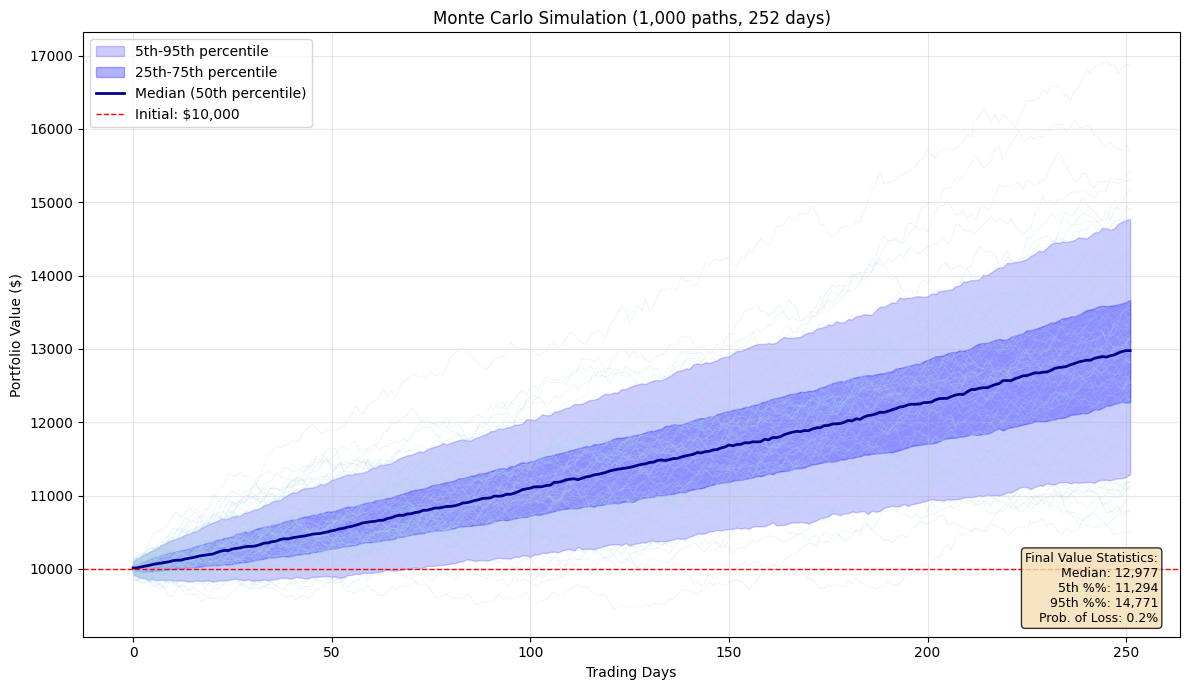

In [39]:
tickers = list(portfolio_tokens.keys())

data_loader = DataLoader(tickers, start_date, end_date)
data = data_loader.fetch_data()
data = data.dropna()  # drops rows where any ticker has no data
print(f"Effective data range: {data.index[0].date()} to {data.index[-1].date()}")

returns = data.pct_change().dropna()

# Flag any ticker with suspicious daily returns
for col in returns.columns:
    max_ret = returns[col].abs().max()
    if max_ret > 0.25:
        print(f"WARNING: {col} has a daily return of {max_ret:.1%} — check data quality")

result = optimize_portfolio(data)

mc_sim = MonteCarloSimulation(
    data,
    weights=result["weights"],
    num_simulations=1000,
    time_horizon=252
)

mc_sim.print_summary()
mc_sim.plot_simulation()

In [41]:
def load_data(tokens):
    data_loader = DataLoader(tickers, start_date, end_date)
    data = data_loader.fetch_data()
    data = data.dropna()  # drops rows where any ticker has no data
    print(f"Effective data range: {data.index[0].date()} to {data.index[-1].date()}")
    
    returns = data.pct_change().dropna()
    
    # Flag any ticker with suspicious daily returns
    for col in returns.columns:
        max_ret = returns[col].abs().max()
        if max_ret > 0.25:
            print(f"WARNING: {col} has a daily return of {max_ret:.1%} — check data quality")

    return data

In [49]:
def fetch_optimize_analyse_simulate(tickers, risk_free_rate=0.0685, num_simulations=1000, time_horizon=252):
    data = load_data(tickers)
    result = optimize_portfolio(data, risk_free_rate)
    print_portfolio_optimization(result)

    mc_sim = MonteCarloSimulation(
        data,
        weights=result["weights"],
        num_simulations=num_simulations,
        time_horizon=time_horizon
    )

    mc_sim.print_summary()
    mc_sim.plot_simulation()

    return result

    
    

Effective data range: 2024-03-18 to 2025-12-31

PORTFOLIO OPTIMIZATION RESULTS

Optimal Weights
------------------------------------------------------------
EBBETF0430.NS     25.00%
GOLDBEES.NS       25.00%
BHARTIARTL.NS     16.73%
MON100.NS         12.47%
HDFCBANK.NS        9.10%
MARUTI.NS          7.00%
BAJFINANCE.NS      2.83%
SBIN.NS            1.74%
HINDUNILVR.NS      0.12%
ITC.NS             0.00%
SUNPHARMA.NS       0.00%
ASIANPAINT.NS      0.00%
AXISBANK.NS        0.00%
HCLTECH.NS         0.00%
ICICIBANK.NS       0.00%
INFY.NS            0.00%
JUNIORBEES.NS      0.00%
KOTAKBANK.NS       0.00%
LT.NS              0.00%
MOSMALL250.NS      0.00%
NIFTYBEES.NS       0.00%
RELIANCE.NS        0.00%
TCS.NS             0.00%
TITAN.NS           0.00%
ULTRACEMCO.NS      0.00%
WIPRO.NS           0.00%
^BSESN             0.00%
^NSEI              0.00%

Portfolio Metrics
------------------------------------------------------------
Expected Annual Return : 26.42%
Annual Volatility      : 8.22%


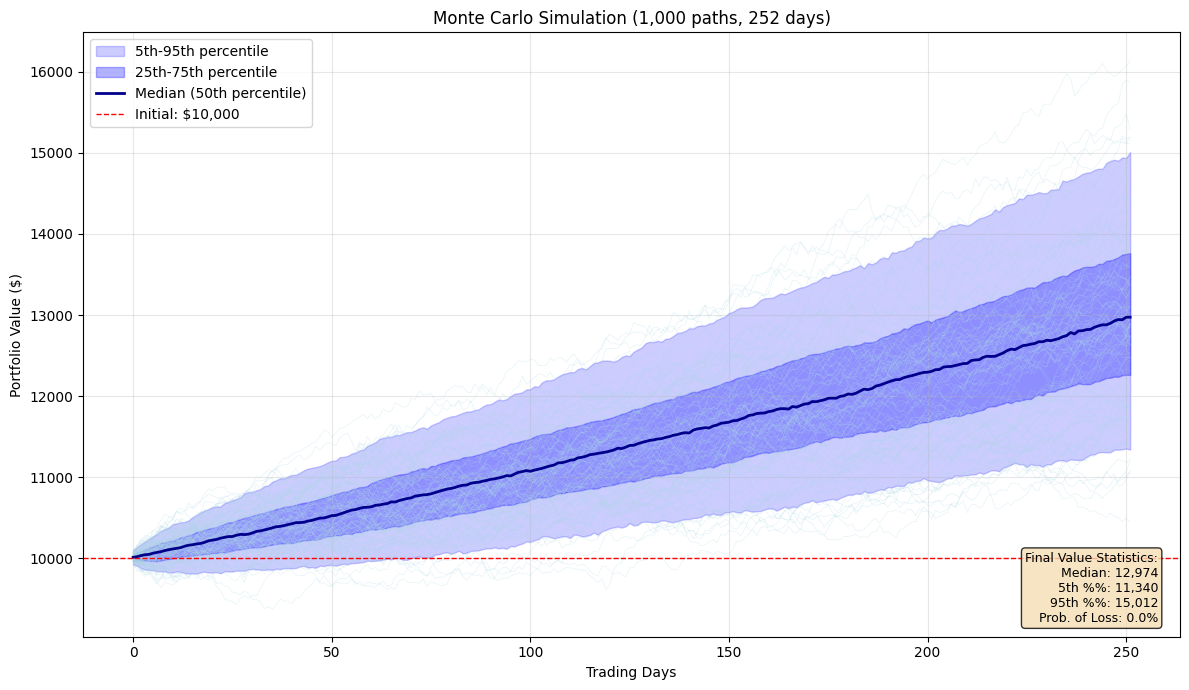

In [50]:
results = fetch_optimize_analyse_simulate(portfolio_tokens.keys())

In [53]:
def run_analysis_pipeline(
    data,
    weights,
    tickers,
    risk_free_rate=0.0685,
    benchmark_ticker='^NSEI'
):
    # Drop zero-weight tickers
    active = [(t, w) for t, w in zip(tickers, weights) if w > 1e-4]
    active_tickers, active_weights = zip(*active)
    active_weights = np.array(active_weights)
    active_data = data[list(active_tickers)]

    print(f"\nActive tickers after optimization: {list(active_tickers)}")

    # 1. Individual metrics (on active tickers only)
    annual_return   = PerformanceMetrics.calculate_annual_return(active_data)
    annual_vol      = PerformanceMetrics.calculate_annual_volatility(active_data)
    sharpe          = PerformanceMetrics.calculate_sharpe_ratio(active_data)
    max_dd          = PerformanceMetrics.calculate_max_drawdown(active_data)
    sortino         = PerformanceMetrics.calculate_sortino_ratio(active_data)
    var             = PerformanceMetrics.calculate_var(active_data)

    print('\n********** Individual Ticker Stats **********')
    print("Annual Return (%):\n",    np.round(100 * annual_return, 2))
    print("Annual Volatility (%):\n",np.round(100 * annual_vol, 2))
    print("Sharpe Ratio:\n",         np.round(sharpe, 2))
    print("Max Drawdown (%):\n",     np.round(100 * max_dd, 2))
    print("Sortino Ratio:\n",        np.round(sortino, 2))
    print("VaR (95%):\n",            np.round(var, 4))

    # 2. Portfolio-level metrics
    pa = PortfolioAnalysis(active_data, active_weights)
    print('\n********** Portfolio Return Stats **********')
    print("Portfolio Return (%):",   np.round(100 * pa.calculate_portfolio_return(), 2))
    print("Portfolio Volatility (%):", np.round(100 * pa.calculate_portfolio_volatility(), 2))
    print("Portfolio Sharpe Ratio:", np.round(pa.calculate_portfolio_sharpe_ratio(), 2))

    # 3. Visualizations
    PortfolioVisualization.plot_performance(active_data)
    PortfolioVisualization.plot_portfolio_return(active_data, active_weights)

    # 4. Benchmark comparison
    benchmark = BenchmarkComparison(
        active_data, active_weights,
        benchmark_ticker=benchmark_ticker,
        risk_free_rate=risk_free_rate
    )
    benchmark.generate_report()
    benchmark.plot_cumulative_returns()

    return active_data, active_weights, list(active_tickers)


Active tickers after optimization: ['BAJFINANCE.NS', 'BHARTIARTL.NS', 'EBBETF0430.NS', 'GOLDBEES.NS', 'HDFCBANK.NS', 'HINDUNILVR.NS', 'MARUTI.NS', 'MON100.NS', 'SBIN.NS']

********** Individual Ticker Stats **********
Annual Return (%):
 Ticker
BAJFINANCE.NS    45.52
BHARTIARTL.NS    33.72
EBBETF0430.NS     8.54
GOLDBEES.NS      71.81
HDFCBANK.NS      13.33
HINDUNILVR.NS     1.37
MARUTI.NS        55.43
MON100.NS         8.13
SBIN.NS          26.04
dtype: float64
Annual Volatility (%):
 Ticker
BAJFINANCE.NS    26.50
BHARTIARTL.NS    21.79
EBBETF0430.NS     3.10
GOLDBEES.NS      16.29
HDFCBANK.NS      18.15
HINDUNILVR.NS    19.47
MARUTI.NS        21.82
MON100.NS        22.08
SBIN.NS          24.01
dtype: float64
Sharpe Ratio:
 Ticker
BAJFINANCE.NS    1.46
BHARTIARTL.NS    1.23
EBBETF0430.NS    0.54
GOLDBEES.NS      3.99
HDFCBANK.NS      0.36
HINDUNILVR.NS   -0.28
MARUTI.NS        2.23
MON100.NS        0.06
SBIN.NS          0.80
dtype: float64
Max Drawdown (%):
 Ticker
BAJFINANCE.NS   -1

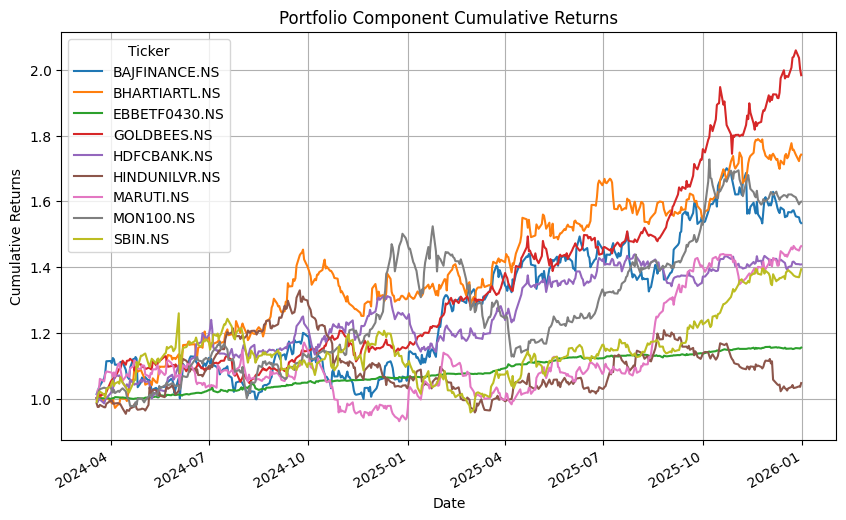

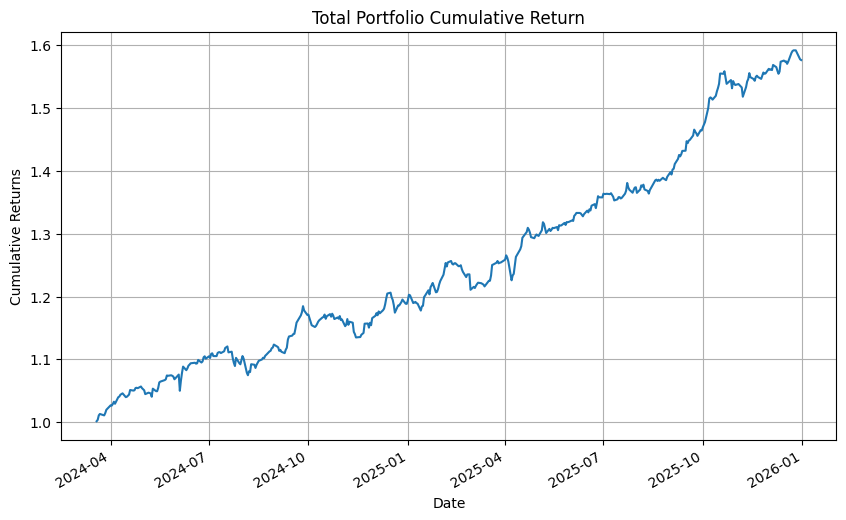


BENCHMARK COMPARISON REPORT
Benchmark: ^NSEI (Nifty 50)
Period: 2024-03-19 to 2025-12-30
------------------------------------------------------------

Annualized Returns:
  Portfolio:  26.52%
  Benchmark:  10.44%
  Difference: +16.08%

Annualized Volatility:
  Portfolio:  8.23%
  Benchmark:  13.07%

Risk Metrics:
  Beta:              0.441
  Alpha (annual):    18.09%
  R-squared:         0.490
  Correlation:       0.700

Performance Metrics:
  Tracking Error:    9.38%
  Information Ratio: 1.714
  Up Capture:        59.5%
  Down Capture:      28.9%


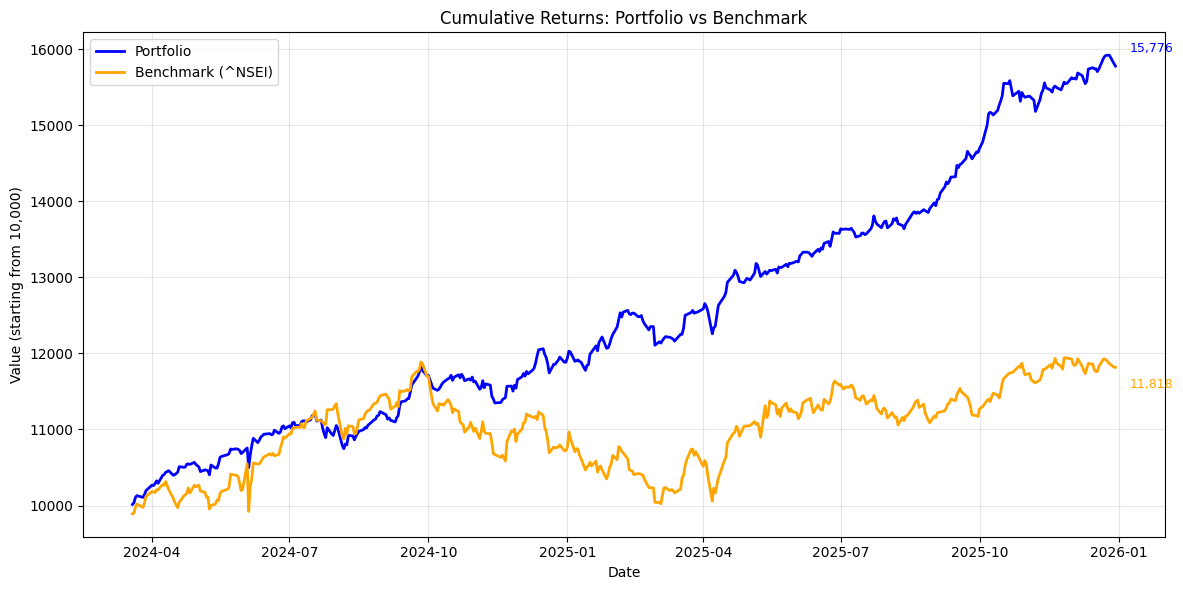

In [54]:
active_data, active_weights, active_tickers = run_analysis_pipeline(
        data,
        weights=results["weights"],
        tickers=results["tickers"],
        risk_free_rate=risk_free_rate
    )